# GOAL model fits – Figure S3 (Gamma prior on the belief SDs)

Uses the posterior traces saved by `exp*_GammaPrior.ipynb` (`sample_exp*.nc`, in this folder).

For each experiment and goal frame:
1. Simulate choices and confidence for the held-out (odd-numbered) trials with the fitted GOAL model.
2. Regress confidence on RT, chosen and unchosen evidence for participants and simulations.
3. Plot the posterior of the belief-variance asymmetry σ<sub>Bel,high</sub> − σ<sub>Bel,low</sub> in both frames.

The last section compares the belief-variance asymmetry between frames.

Figures are saved to `figs/`.

In [11]:
import os
os.environ["PYTENSOR_FLAGS"] = "mode=FAST_RUN,device=cpu,optimizer=fast_compile,cxx="

In [12]:
import pymc as pm
import pandas as pd
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from scipy import stats
import seaborn as sns
import  pytensor.tensor as pt

import functionsSims as fs
import functionsRegress as freg

In [13]:
import pytensor
pytensor.config.cxx = ""   # disables C compilation
pytensor.config.optimizer = "fast_compile"

In [14]:
# Seed for the held-out simulations
RANDOM_SEED = 58
rng = np.random.default_rng(RANDOM_SEED)

In [15]:
# Exp 1-2: z-score evidence/confidence/RT within participant, split even (fit) / odd (test) trials,
# and get the low/high evidence means from a median split (plotted by fs.split_values_highLow; Figure S2)
def mainLoad(data_part_all0):

    # z-score values
    data_part_all0['zLValue'] = fs.zscore1(data_part_all0,'LValue', 'Part')
    data_part_all0['zRValue'] = fs.zscore1(data_part_all0,'RValue', 'Part')
    data_part_all0['zConf'] = fs.zscore1(data_part_all0,'Conf', 'Part')
    data_part_all0['zRT'] = fs.zscore1(data_part_all0,'ChoiceRT', 'Part')

    # estimate choice and confidence compound
    data_part_all0['choiceConf'] = data_part_all0.Conf * (2*data_part_all0.ChosenITM-1) # second term is to transform choice to left : -1; right: +1
    data_part_all0['zChoiceConf'] = fs.zscore1(data_part_all0,'choiceConf', 'Part')

    data_part_all = data_part_all0.loc[data_part_all0.TrialN%2 == 0]
    data_part_all_test = data_part_all0.loc[data_part_all0.TrialN%2 == 1]

    # load input 
    val_a = data_part_all.zLValue.values
    val_b = data_part_all.zRValue.values
    chosenByPart = data_part_all.ChosenITM.values
    rtByPart = data_part_all.zRT.values

    value_sort = data_part_all.copy()
    value_sort = value_sort.zLValue.values

    confByPart = data_part_all.zConf.values
    choiceConfByPart = data_part_all.zChoiceConf.values

    confNormByPart = fs.norm01(data_part_all,'zConf','Part')

    delta_og = data_part_all.zLValue

    lvalParam, hvalParam = fs.split_values_highLow (value_sort)

    return val_a, val_b, chosenByPart, rtByPart, lvalParam, hvalParam, confByPart, confNormByPart, choiceConfByPart, data_part_all, data_part_all_test   

In [16]:
# Exp 4: rename columns to the common format (clicks left/right = LValue/RValue), then as mainLoad
def mainLoad_exp4(data_part_all0):

    data_part_all0 = data_part_all0.rename(columns = {'Choice':'ChosenITM','Choice_SND1_RT':'ChoiceRT' ,'CONF': 'Conf', 
                                                    'freql':'LValue','freqr':'RValue','part':'Part','Trial_Index_': 'TrialN' })

    data_part_all0['AbsDV'] = np.abs(data_part_all0['LValue'] - data_part_all0['RValue'])
    data_part_all0['zAbsDV'] = fs.zscore1(data_part_all0,'AbsDV', 'Part')

    data_part_all0['TotVal'] = np.abs(data_part_all0['LValue'] + data_part_all0['RValue'])
    data_part_all0['zTotVal'] = fs.zscore1(data_part_all0,'TotVal', 'Part')

    # z-score values
    data_part_all0['zLValue'] = fs.zscore1(data_part_all0,'LValue', 'Part')
    data_part_all0['zRValue'] = fs.zscore1(data_part_all0,'RValue', 'Part')
    data_part_all0['zConf'] = fs.zscore1(data_part_all0,'Conf', 'Part')
    data_part_all0['zRT'] = fs.zscore1(data_part_all0,'ChoiceRT', 'Part')

    # estimate choice and confidence compound
    data_part_all0['choiceConf'] = data_part_all0.Conf * (2*data_part_all0.ChosenITM-1) # second term is to transform choice to left : -1; right: +1
    data_part_all0['zChoiceConf'] = fs.zscore1(data_part_all0,'choiceConf', 'Part')

    data_part_all = data_part_all0.loc[data_part_all0.TrialN%2 == 0]
    data_part_all_test = data_part_all0.loc[data_part_all0.TrialN%2 == 1]

    # load input 
    val_a = data_part_all.zLValue.values
    val_b = data_part_all.zRValue.values
    chosenByPart = data_part_all.ChosenITM.values
    rtByPart = data_part_all.zRT.values

    value_sort = data_part_all.copy()
    value_sort = value_sort.zLValue.values

    confByPart = data_part_all.zConf.values
    choiceConfByPart = data_part_all.zChoiceConf.values

    confNormByPart = fs.norm01(data_part_all,'zConf','Part')

    lvalParam, hvalParam = fs.split_values_highLow (value_sort)
    return val_a, val_b, chosenByPart, rtByPart, lvalParam, hvalParam, confByPart, confNormByPart, choiceConfByPart, data_part_all, data_part_all_test   

In [17]:
# Exp 3: evidence = dot number x coherence for each direction, then as mainLoad
def mainLoad_exp3(data_part_all0):
   
# z-score values
    data_part_all0['LDotNum'] = data_part_all0['Dot Num']*data_part_all0['LCoh']
    data_part_all0['RDotNum'] = data_part_all0['Dot Num']*data_part_all0['RCoh']
    data_part_all0['AbsDDotNum'] = np.abs(data_part_all0['RDotNum'] - data_part_all0['LDotNum'])
    data_part_all0['zLValue'] = fs.zscore1(data_part_all0,'LDotNum', 'Part')
    data_part_all0['zRValue'] = fs.zscore1(data_part_all0,'RDotNum', 'Part')
    data_part_all0['zAbsDDotNum'] = fs.zscore1(data_part_all0,'AbsDDotNum', 'Part')
    
    data_part_all0['TotVal'] = data_part_all0['LDotNum'] + data_part_all0['RDotNum']
    data_part_all0['zTotVal'] = fs.zscore1(data_part_all0,'TotVal', 'Part')

    data_part_all0['zLCoh'] = fs.zscore1(data_part_all0,'LCoh', 'Part')
    data_part_all0['zRCoh'] = fs.zscore1(data_part_all0,'RCoh', 'Part')
    data_part_all0['zConf'] = fs.zscore1(data_part_all0,'Confidence', 'Part')
    data_part_all0['zDotNum'] = fs.zscore1(data_part_all0,'Dot Num', 'Part')
    data_part_all0['zRT'] = fs.zscore1(data_part_all0,'Reaction Time', 'Part')

    # estimate choice and confidence compound
    data_part_all0['choiceConf'] = data_part_all0.Conf * (2*data_part_all0.Choice-1) # second term is to transform choice to left : -1; right: +1
    data_part_all0['zChoiceConf'] = fs.zscore1(data_part_all0,'choiceConf', 'Part')

    data_part_all0 = data_part_all0.rename(columns = {'Choice':'ChosenITM', 'zAbsDDotNum':'zAbsDV'})

    data_part_all = data_part_all0.loc[data_part_all0.TrialNN%2 == 0]
    data_part_all_test = data_part_all0.loc[data_part_all0.TrialNN%2 == 1]

    # load input 
    val_a = data_part_all.zLValue.values.copy()
    val_b = data_part_all.zRValue.values.copy()

    abs_d_dots = data_part_all.zAbsDV.values.copy()

    chosenByPart = data_part_all.ChosenITM.values
    rtByPart = data_part_all.zRT.values

    value_sort = data_part_all.copy()
    value_sort = value_sort.zLValue.values

    confByPart = data_part_all.zConf.values
    choiceConfByPart = data_part_all.zChoiceConf.values

    confNormByPart = fs.norm01(data_part_all,'zConf','Part')

    lvalParam, hvalParam = fs.split_values_highLow (value_sort)

    return val_a, val_b, chosenByPart, rtByPart, lvalParam, hvalParam, confByPart, confNormByPart, choiceConfByPart, data_part_all, data_part_all_test   

In [18]:
# Simulate choices and confidence for the held-out (odd) trials of one frame:
# the GOAL model with parameters fixed at their posterior means, sampled with pm.sample_prior_predictive
def genSims(trace,data_part_all_test):
    sbel1_f = np.mean(trace.posterior['sigmaBel1'].values.flatten())
    sbel2_f = np.mean(trace.posterior['sigmaBel2'].values.flatten())
    beta_f = np.mean(trace.posterior['beta'].values.flatten())
    betaConf_f = np.mean(trace.posterior['betaConf'].values.flatten())
    betaRT_f = np.mean(trace.posterior['betaRT'].values.flatten())

    val_a_test = data_part_all_test['zLValue'].values
    val_b_test = data_part_all_test['zRValue'].values
    rtByPart_test = data_part_all_test['zRT'].values

    # params for the generative model: mean and std
    mu = [lvalParam[0],hvalParam[0]]
        
    with pm.Model() as sims_peb:
        # get value for each trial, generate sample for each 
        sigmaGen1 = sbel1_f
        sigmaGen2 = sbel2_f
        
        lVal = pm.Normal('lVal', mu = val_a_test, sigma = 0.001 )
        rVal = pm.Normal('rVal', mu = val_b_test, sigma = 0.001 )
        
        # estimate odds ratio for the choice of right option
        
        LLR = pm.Deterministic('LLR',  pt.log(1/(sigmaGen2 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(rVal - mu[1] , 2.) / (2 * pt.power(sigmaGen2, 2.)))) - 
                                        pt.log(1/(sigmaGen1 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(rVal - mu[0] , 2.) / (2 * pt.power(sigmaGen1, 2.)))) + 
                                        pt.log(1/(sigmaGen1 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(lVal - mu[0] , 2.) / (2 * pt.power(sigmaGen1, 2.)))) -
                                        pt.log(1/(sigmaGen2 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(lVal - mu[1] , 2.) / (2 * pt.power(sigmaGen2, 2.))))  )

        beta = beta_f
        betaConf = betaConf_f
        betaRT = betaRT_f

        p = pm.Deterministic("p", 1.0/(1. + pt.exp(beta*LLR) ))    
        
        choice = pm.Bernoulli("choice", p)

        conf = pm.Deterministic("conf",1.0/(1. + pt.exp(betaConf*pt.abs(LLR) + betaRT*rtByPart_test)) )

        confRep = pm.Normal('confReport',mu = conf, sigma=0.025)  

        traceSims = pm.sample_prior_predictive(random_seed=rng)

    return traceSims,rtByPart_test        

In [20]:
# Figure panels: confidence ~ chosen + unchosen evidence (+ RT, not shown) for humans and model simulations
# in each frame, and the posterior of sigmaBel,high - sigmaBel,low for both frames
def plotSims_reduced(trace_neg, trace_pos,
             regParamH_pos, lowLimH_pos, highLimH_pos,
             regParamSov_pos, lowLimSov_pos, highLimSov_pos,
             regParamH_neg, lowLimH_neg, neg_highLimH,
             neg_regParamSov, neg_lowLimSov, neg_highLimSov,
             label=['Like','Dislike'], figname='figReg'):

    colorP = '#4F6A9A','#B5C8E9','#AC5255','#F2CECF'
    width_bars = 0.4
    plt.figure(figsize=(15,6))
    bins = 20

    #change fonts
    plt.rcParams.update({'font.size': 14})
    plt.rcParams.update({'font.family': 'arial'})

    # ----------------
    # POSITIVE FRAME
    # ----------------
    regParamH = regParamH_pos[1:]      # drop RT
    lowLimH = lowLimH_pos[1:]
    highLimH = highLimH_pos[1:]
    regParamSov = regParamSov_pos[1:]
    lowLimSov = lowLimSov_pos[1:]
    highLimSov = highLimSov_pos[1:]

    plt.subplot(1,3,1)
    plt.bar(np.add(range(len(regParamH)),0)/2, regParamH,
            yerr=np.abs(lowLimH - highLimH)/2,
            color=[colorP[0]], width=width_bars, label='Human')
    plt.bar(np.add(range(len(regParamSov)),2)/2, regParamSov,
            yerr=np.abs(lowLimSov - highLimSov)/2,
            color=[colorP[1]], width=width_bars, label='Model Sim')
    plt.axhline(0, color='black', lw=2, alpha=0.5)

    plt.ylabel("Regression Coefficient")
    plt.title('Confidence ' + label[0])
    plt.xticks([0,0.5,1,1.5],['Chosen','Unchosen','Chosen','Unchosen'],rotation=90)
    plt.legend(frameon=False)
    sns.despine()

    # ----------------
    # NEGATIVE FRAME
    # ----------------
    regParamH = regParamH_neg[1:]      # drop RT
    lowLimH = lowLimH_neg[1:]
    highLimH = neg_highLimH[1:]
    regParamSov = neg_regParamSov[1:]
    lowLimSov = neg_lowLimSov[1:]
    highLimSov = neg_highLimSov[1:]

    plt.subplot(1,3,2)
    plt.bar(np.add(range(len(regParamH)),0)/2, regParamH,
            yerr=np.abs(lowLimH - highLimH)/2,
            color=[colorP[2]], width=width_bars, label='Human')
    plt.bar(np.add(range(len(regParamSov)),2)/2, regParamSov,
            yerr=np.abs(lowLimSov - highLimSov)/2,
            color=[colorP[3]], width=width_bars, label='Model Sim')
    plt.axhline(0, color='black', lw=2, alpha=0.5)

    plt.title('Confidence ' + label[1])
    plt.xticks([0,0.5,1,1.5],['Chosen','Unchosen','Chosen','Unchosen'],rotation=90)
    plt.legend(frameon=False)
    sns.despine()

    # ----------------
    # BELIEF VARIANCE HISTOGRAM (unchanged)
    # ----------------
    plt.subplot(1,3,3)
    sBel1 = trace_pos.posterior['sigmaBel1'].values.flatten()
    sBel2 = trace_pos.posterior['sigmaBel2'].values.flatten()
    var1_high = sBel2- sBel1
    plt.hist(var1_high, bins=bins, color=colorP[0],label=label[0])

    sBel1 = trace_neg.posterior['sigmaBel1'].values.flatten()
    sBel2 = trace_neg.posterior['sigmaBel2'].values.flatten()
    var1_low = sBel2- sBel1
    plt.hist(var1_low, bins=bins, color=colorP[2], label=label[1]) 
    plt.axvline(0, color='black', linestyle="--")

    plt.xlabel("$\sigma_{Bel,high}$ - $\sigma_{Bel,low}$",fontsize=19)
    plt.ylabel("Density")
    plt.legend(frameon=False)

    sns.despine()
    plt.savefig('figs/'+figname+'_reduced.pdf', format='pdf', dpi=1000)
    plt.show()

## Experiment 1 – value-based choice (Like / Dislike)

================  Like frame =====================
mean values -> high: 0.6788287640343346 ,  low:-0.8083217543745521
stdev values -> high: 0.6788287640343346 ,  low:0.4861710699343596
low values distribution: mean:-0.8083217543745521, var:0.4861710699343596
high values distribution: mean:0.7928236783310723, var:0.6788287640343346


Sampling: [choice, confReport, lVal, rVal]


------------SIMS SUMMARY CONF vs chosen + unchosen ------------------ 
                            OLS Regression Results                            
Dep. Variable:                  zConf   R-squared:                       0.611
Model:                            OLS   Adj. R-squared:                  0.611
Method:                 Least Squares   F-statistic:                 4.875e+05
Date:                Tue, 28 Jul 2026   Prob (F-statistic):               0.00
Time:                        00:03:40   Log-Likelihood:            -8.8022e+05
No. Observations:              930000   AIC:                         1.760e+06
Df Residuals:                  929996   BIC:                         1.761e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

Sampling: [choice, confReport, lVal, rVal]


------------SIMS SUMMARY CONF vs chosen + unchosen ------------------ 
                            OLS Regression Results                            
Dep. Variable:                  zConf   R-squared:                       0.615
Model:                            OLS   Adj. R-squared:                  0.615
Method:                 Least Squares   F-statistic:                 4.959e+05
Date:                Tue, 28 Jul 2026   Prob (F-statistic):               0.00
Time:                        00:06:48   Log-Likelihood:            -8.7533e+05
No. Observations:              930000   AIC:                         1.751e+06
Df Residuals:                  929996   BIC:                         1.751e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

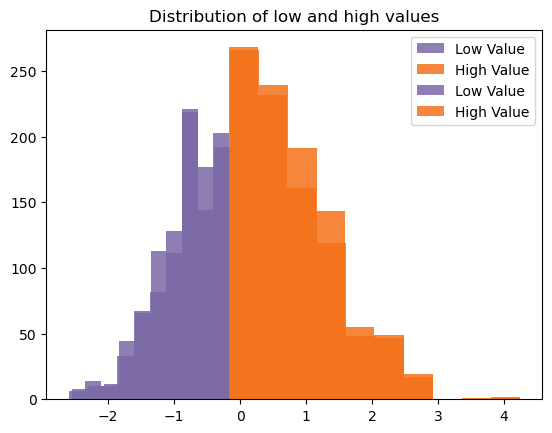

In [11]:
# Load the fitted posteriors, simulate held-out trials for each frame and regress confidence on
# RT + chosen + unchosen evidence for participants (Human) and simulations (Model Sim)
trace_exp1_pos = az.from_netcdf("sample_exp1_like_gammaPrior.nc")
trace_exp1_neg = az.from_netcdf("sample_exp1_dislike_gammaPrior.nc")

data_all = pd.read_csv('../Data/Sepulveda2020/DataFoodFramingNotebook_31.csv') 

# Like frame

print('================  Like frame =====================')

data_part_all0 =  data_all.loc[data_all.BlockCond == 1]
val_a, val_b, chosenByPart, rtByPart, lvalParam, hvalParam, confByPart, confNormByPart, choiceConfByPart, data_part_all, data_part_all_test      = mainLoad(data_part_all0)
traceSims_pos,rtByPart_test = genSims(trace_exp1_pos,data_part_all_test)
exp1_regParamH_pos, exp1_lowLimH_pos, exp1_highLimH_pos, exp1_regParamSov_pos, exp1_lowLimSov_pos, exp1_highLimSov_pos = freg.exp_genRegression(traceSims_pos,data_part_all_test,rtByPart_test)

# Dislike frame

print('================  Dislike frame =====================')
data_part_all0 =  data_all.loc[data_all.BlockCond == 2] 
val_a, val_b, chosenByPart, rtByPart, lvalParam, hvalParam, confByPart, confNormByPart, choiceConfByPart, data_part_all, data_part_all_test      = mainLoad(data_part_all0)
traceSims_neg,rtByPart_test = genSims(trace_exp1_neg,data_part_all_test)
exp1_regParamH_neg, exp1_lowLimH_neg, exp1_neg_highLimH, exp1_neg_regParamSov, exp1_neg_lowLimSov, exp1_neg_highLimSov = freg.exp_genRegression(traceSims_neg,data_part_all_test,rtByPart_test)

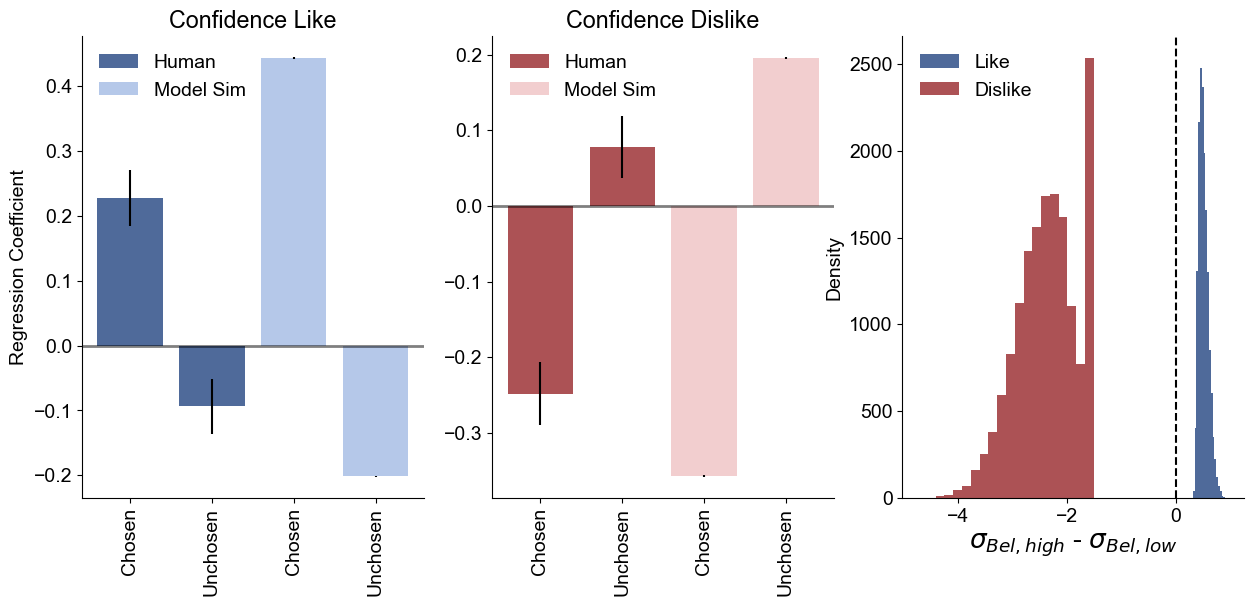

In [12]:
# Figure S3A-C: regression coefficients (Human vs Model Sim) and belief-variance asymmetry
plotSims_reduced (trace_exp1_neg,trace_exp1_pos,
          exp1_regParamH_pos, exp1_lowLimH_pos, exp1_highLimH_pos, exp1_regParamSov_pos, exp1_lowLimSov_pos, exp1_highLimSov_pos, 
          exp1_regParamH_neg, exp1_lowLimH_neg, exp1_neg_highLimH, exp1_neg_regParamSov, exp1_neg_lowLimSov, exp1_neg_highLimSov, label = ['Like','Dislike'],figname = 'figReg_gamma_reduced_exp1')

## Experiment 2 – perceptual choice (Most / Fewest)

================  More frame =====================
mean values -> high: 0.551336478887459 ,  low:-0.7816342591990628
stdev values -> high: 0.551336478887459 ,  low:0.5137262728786748
low values distribution: mean:-0.7816342591990628, var:0.5137262728786748
high values distribution: mean:0.8032799078504699, var:0.551336478887459


Sampling: [choice, confReport, lVal, rVal]


------------SIMS SUMMARY CONF vs chosen + unchosen ------------------ 
                            OLS Regression Results                            
Dep. Variable:                  zConf   R-squared:                       0.898
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                 2.832e+06
Date:                Tue, 28 Jul 2026   Prob (F-statistic):               0.00
Time:                        00:12:02   Log-Likelihood:            -2.6415e+05
No. Observations:              960000   AIC:                         5.283e+05
Df Residuals:                  959996   BIC:                         5.284e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

Sampling: [choice, confReport, lVal, rVal]


------------SIMS SUMMARY CONF vs chosen + unchosen ------------------ 
                            OLS Regression Results                            
Dep. Variable:                  zConf   R-squared:                       0.876
Model:                            OLS   Adj. R-squared:                  0.876
Method:                 Least Squares   F-statistic:                 2.252e+06
Date:                Tue, 28 Jul 2026   Prob (F-statistic):               0.00
Time:                        00:14:50   Log-Likelihood:            -3.6186e+05
No. Observations:              960000   AIC:                         7.237e+05
Df Residuals:                  959996   BIC:                         7.238e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

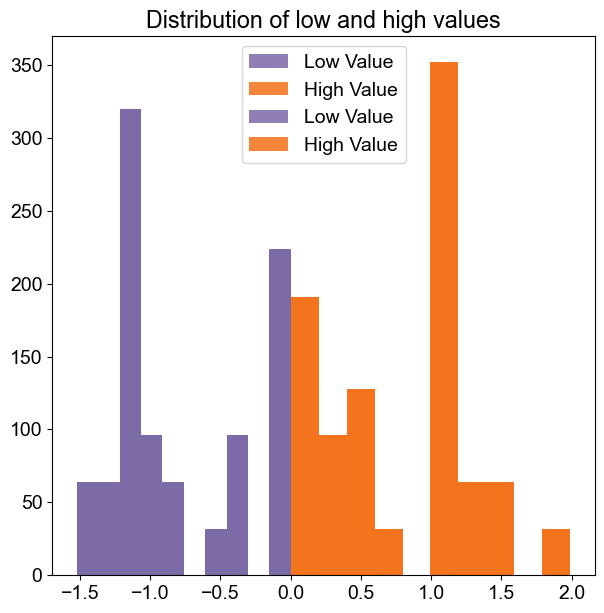

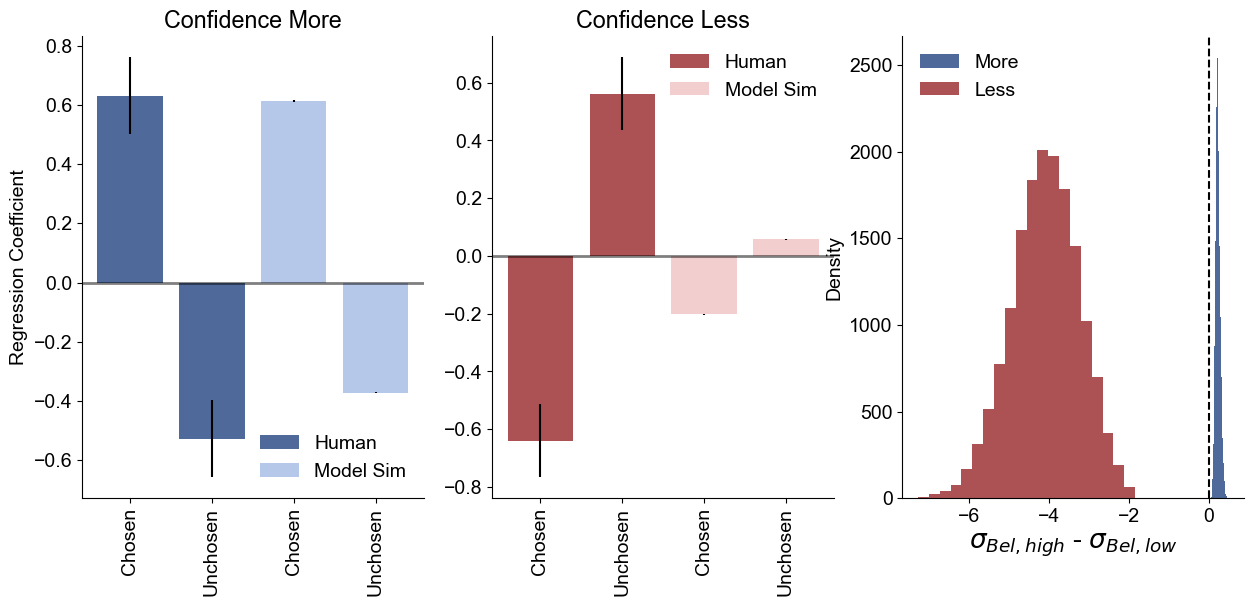

In [14]:
# Load the fitted posteriors, simulate held-out trials for each frame and regress confidence on
# RT + chosen + unchosen evidence for participants (Human) and simulations (Model Sim)
trace_exp_pos = az.from_netcdf("sample_exp2_more_gamma.nc")
trace_exp_neg = az.from_netcdf("sample_exp2_less_gamma.nc")

data_all = pd.read_csv('../Data/Sepulveda2020/DataPerceptualFramingNotebook.csv') 
# More frame

print('================  More frame =====================')

data_part_all0 =  data_all.loc[data_all.BlockCond == 'MORE']
val_a, val_b, chosenByPart, rtByPart, lvalParam, hvalParam, confByPart, confNormByPart, choiceConfByPart, data_part_all, data_part_all_test      = mainLoad(data_part_all0)
traceSims_pos,rtByPart_test = genSims(trace_exp_pos,data_part_all_test)
exp_regParamH_pos, exp_lowLimH_pos, exp_highLimH_pos, exp_regParamSov_pos, exp_lowLimSov_pos, exp_highLimSov_pos = freg.exp_genRegression(traceSims_pos,data_part_all_test,rtByPart_test)

# Less frame

print('================  Less frame =====================')
data_part_all0 =  data_all.loc[data_all.BlockCond == 'LESS'] 
val_a, val_b, chosenByPart, rtByPart, lvalParam, hvalParam, confByPart, confNormByPart, choiceConfByPart, data_part_all, data_part_all_test      = mainLoad(data_part_all0)
traceSims_neg,rtByPart_test = genSims(trace_exp_neg,data_part_all_test)
exp_regParamH_neg, exp_lowLimH_neg, exp_neg_highLimH, exp_neg_regParamSov, exp_neg_lowLimSov, exp_neg_highLimSov = freg.exp_genRegression(traceSims_neg,data_part_all_test,rtByPart_test)

# Figure S3D-F: regression coefficients (Human vs Model Sim) and belief-variance asymmetry
plotSims_reduced (trace_exp_neg,trace_exp_pos,
          exp_regParamH_pos, exp_lowLimH_pos, exp_highLimH_pos, exp_regParamSov_pos, exp_lowLimSov_pos, exp_highLimSov_pos, 
          exp_regParamH_neg, exp_lowLimH_neg, exp_neg_highLimH, exp_neg_regParamSov, exp_neg_lowLimSov, exp_neg_highLimSov, label = ['More','Less'],figname = 'figReg_gamma_reduced_exp2')

## Experiment 4 – auditory clicks (High / Low Clicks)

================  Click high =====================
mean values -> high: 0.5189653617301986 ,  low:-0.9114899485458068
stdev values -> high: 0.5189653617301986 ,  low:0.4737139737424027
low values distribution: mean:-0.9114899485458068, var:0.4737139737424027
high values distribution: mean:0.837461212727064, var:0.5189653617301986


Sampling: [choice, confReport, lVal, rVal]


------------SIMS SUMMARY CONF vs chosen + unchosen ------------------ 
                            OLS Regression Results                            
Dep. Variable:                  zConf   R-squared:                       0.853
Model:                            OLS   Adj. R-squared:                  0.853
Method:                 Least Squares   F-statistic:                 1.392e+06
Date:                Tue, 28 Jul 2026   Prob (F-statistic):               0.00
Time:                        00:16:54   Log-Likelihood:            -3.3159e+05
No. Observations:              720000   AIC:                         6.632e+05
Df Residuals:                  719996   BIC:                         6.632e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

Sampling: [choice, confReport, lVal, rVal]


------------SIMS SUMMARY CONF vs chosen + unchosen ------------------ 
                            OLS Regression Results                            
Dep. Variable:                  zConf   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.874
Method:                 Least Squares   F-statistic:                 1.669e+06
Date:                Tue, 28 Jul 2026   Prob (F-statistic):               0.00
Time:                        00:18:52   Log-Likelihood:            -2.7472e+05
No. Observations:              719500   AIC:                         5.495e+05
Df Residuals:                  719496   BIC:                         5.495e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

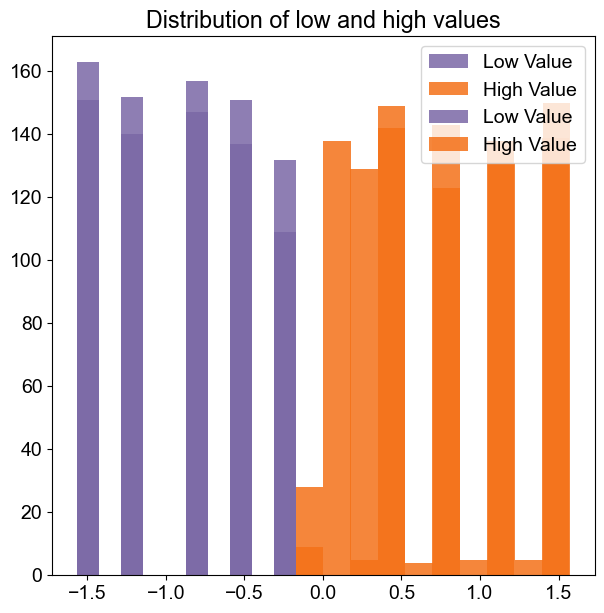

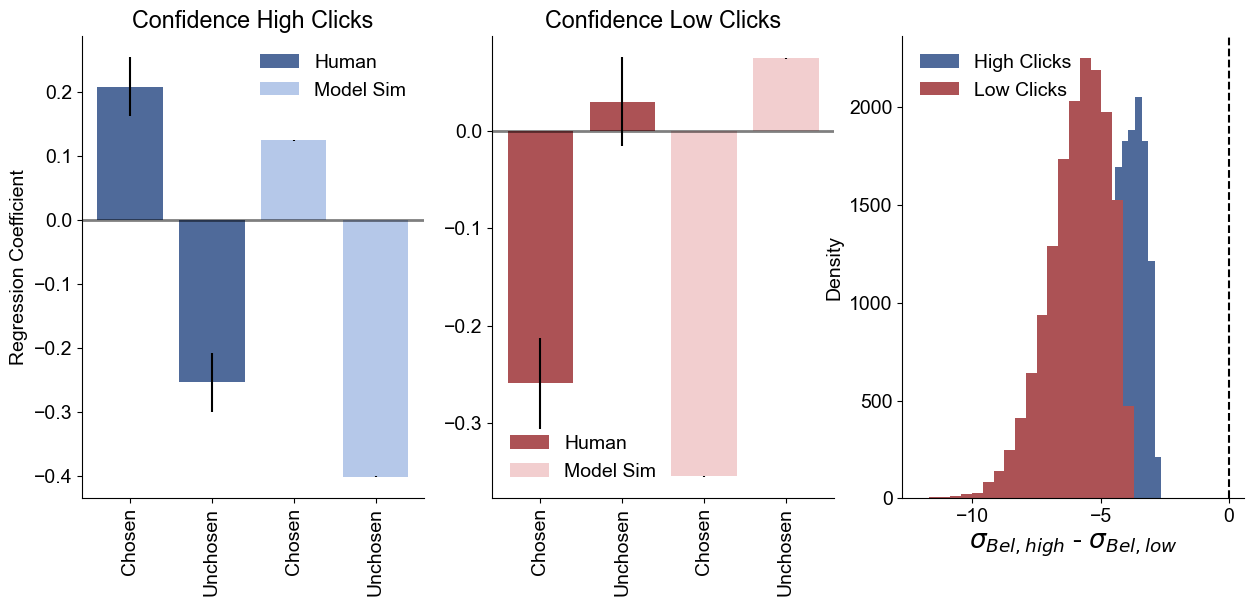

In [15]:
# Load the fitted posteriors, simulate held-out trials for each frame and regress confidence on
# RT + chosen + unchosen evidence for participants (Human) and simulations (Model Sim)
trace_exp_pos = az.from_netcdf("sample_exp4_soundHigh_gammaPrior.nc")
trace_exp_neg = az.from_netcdf("sample_exp4_soundLow_gammaPrior.nc")

data_all = pd.read_csv('../Data/SepulvedaNew/Pupil2022_FullData_Dec2022.csv')
# Click high

print('================  Click high =====================')

data_part_all0 =  data_all.loc[data_all.frame == 1]
val_a, val_b, chosenByPart, rtByPart, lvalParam, hvalParam, confByPart, confNormByPart, choiceConfByPart, data_part_all, data_part_all_test      = mainLoad_exp4(data_part_all0)
traceSims_pos,rtByPart_test = genSims(trace_exp_pos,data_part_all_test)
exp_regParamH_pos, exp_lowLimH_pos, exp_highLimH_pos, exp_regParamSov_pos, exp_lowLimSov_pos, exp_highLimSov_pos = freg.exp_genRegression(traceSims_pos,data_part_all_test,rtByPart_test)

# Click Low

print('================  Click Low =====================')
data_part_all0 =  data_all.loc[data_all.frame == 2] 
val_a, val_b, chosenByPart, rtByPart, lvalParam, hvalParam, confByPart, confNormByPart, choiceConfByPart, data_part_all, data_part_all_test      = mainLoad_exp4(data_part_all0)
traceSims_neg,rtByPart_test = genSims(trace_exp_neg,data_part_all_test)
exp_regParamH_neg, exp_lowLimH_neg, exp_neg_highLimH, exp_neg_regParamSov, exp_neg_lowLimSov, exp_neg_highLimSov = freg.exp_genRegression(traceSims_neg,data_part_all_test,rtByPart_test)

# Figure S3J-L: regression coefficients (Human vs Model Sim) and belief-variance asymmetry
plotSims_reduced (trace_exp_neg,trace_exp_pos,
          exp_regParamH_pos, exp_lowLimH_pos, exp_highLimH_pos, exp_regParamSov_pos, exp_lowLimSov_pos, exp_highLimSov_pos, 
          exp_regParamH_neg, exp_lowLimH_neg, exp_neg_highLimH, exp_neg_regParamSov, exp_neg_lowLimSov, exp_neg_highLimSov, label = ['High Clicks','Low Clicks'],figname = 'figReg_gamma_reduced_exp4')

## Experiment 3 – dot motion (High / Low Motion)

================  High Motion =====================
mean values -> high: 0.7695899446001397 ,  low:-0.8057340282485334
stdev values -> high: 0.7695899446001397 ,  low:0.3340805272887706
low values distribution: mean:-0.8057340282485334, var:0.3340805272887706
high values distribution: mean:0.7863885015105995, var:0.7695899446001397


Sampling: [choice, confReport, lVal, rVal]


------------SIMS SUMMARY CONF vs chosen + unchosen ------------------ 
                            OLS Regression Results                            
Dep. Variable:                  zConf   R-squared:                       0.778
Model:                            OLS   Adj. R-squared:                  0.778
Method:                 Least Squares   F-statistic:                 1.898e+06
Date:                Mon, 10 Aug 2026   Prob (F-statistic):               0.00
Time:                        17:23:02   Log-Likelihood:            -1.0871e+06
No. Observations:             1629000   AIC:                         2.174e+06
Df Residuals:                 1628996   BIC:                         2.174e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

Sampling: [choice, confReport, lVal, rVal]


------------SIMS SUMMARY CONF vs chosen + unchosen ------------------ 
                            OLS Regression Results                            
Dep. Variable:                  zConf   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                 2.503e+06
Date:                Mon, 10 Aug 2026   Prob (F-statistic):               0.00
Time:                        17:27:30   Log-Likelihood:            -8.9710e+05
No. Observations:             1619000   AIC:                         1.794e+06
Df Residuals:                 1618996   BIC:                         1.794e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

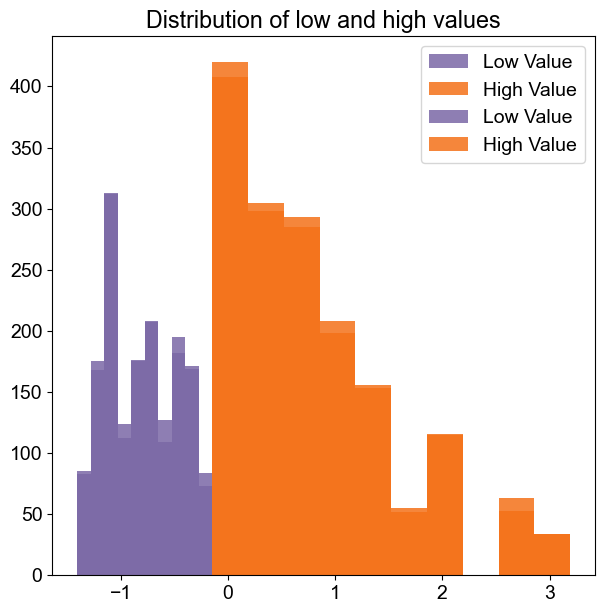

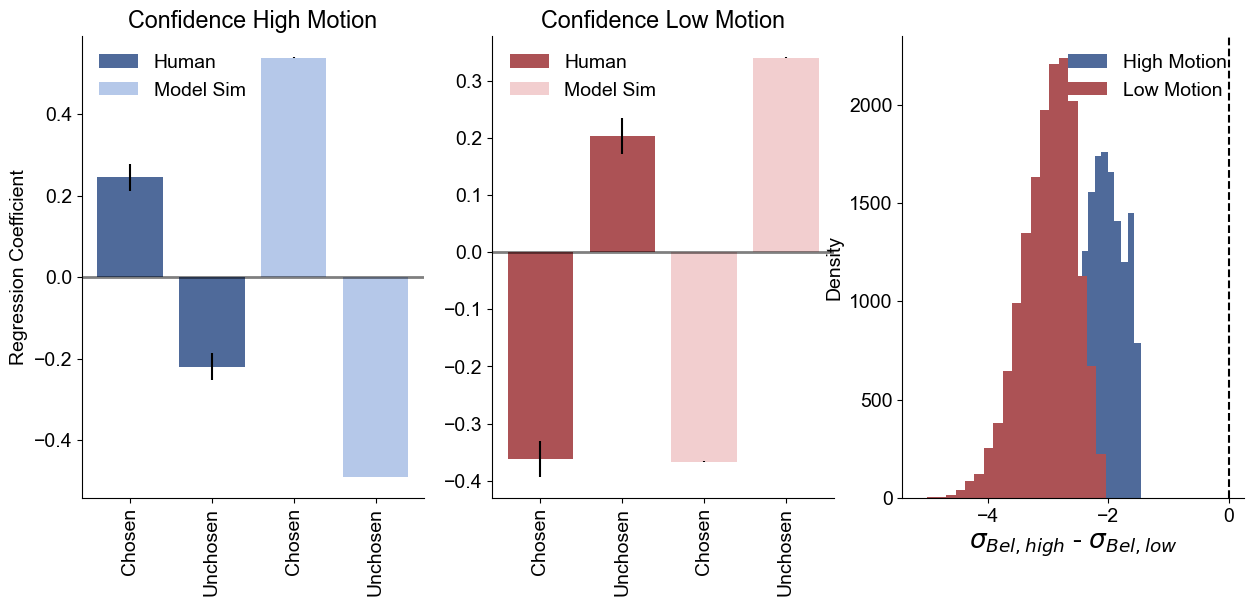

In [24]:
# Load the fitted posteriors, simulate held-out trials for each frame and regress confidence on
# RT + chosen + unchosen evidence for participants (Human) and simulations (Model Sim)
trace_exp_pos = az.from_netcdf("sample_exp3_HighMotion_gammaPrior_v2.nc")
trace_exp_neg = az.from_netcdf("sample_exp3_LowMotion_gammaPrior.nc")

data_all = pd.read_csv('../Data/SepulvedaNew/RDMFrame_FullProlificData_CoherenceControl_Apr2021.csv')

# High Motion

print('================  High Motion =====================')

data_part_all0 =  data_all.loc[data_all.Frame == 1]
val_a, val_b, chosenByPart, rtByPart, lvalParam, hvalParam, confByPart, confNormByPart, choiceConfByPart, data_part_all, data_part_all_test      = mainLoad_exp3(data_part_all0)
traceSims_pos,rtByPart_test = genSims(trace_exp_pos,data_part_all_test)
exp_regParamH_pos, exp_lowLimH_pos, exp_highLimH_pos, exp_regParamSov_pos, exp_lowLimSov_pos, exp_highLimSov_pos = freg.exp_genRegression(traceSims_pos,data_part_all_test,rtByPart_test)

# Low Motion

print('================  Low Motion =====================')
data_part_all0 =  data_all.loc[data_all.Frame == 2] 
val_a, val_b, chosenByPart, rtByPart, lvalParam, hvalParam, confByPart, confNormByPart, choiceConfByPart, data_part_all, data_part_all_test      = mainLoad_exp3(data_part_all0)
traceSims_neg,rtByPart_test = genSims(trace_exp_neg,data_part_all_test)
exp_regParamH_neg, exp_lowLimH_neg, exp_neg_highLimH, exp_neg_regParamSov, exp_neg_lowLimSov, exp_neg_highLimSov = freg.exp_genRegression(traceSims_neg,data_part_all_test,rtByPart_test)

# Figure S3G-I: regression coefficients (Human vs Model Sim) and belief-variance asymmetry
plotSims_reduced (trace_exp_neg,trace_exp_pos,
          exp_regParamH_pos, exp_lowLimH_pos, exp_highLimH_pos, exp_regParamSov_pos, exp_lowLimSov_pos, exp_highLimSov_pos, 
          exp_regParamH_neg, exp_lowLimH_neg, exp_neg_highLimH, exp_neg_regParamSov, exp_neg_lowLimSov, exp_neg_highLimSov, label = ['High Motion','Low Motion'],figname = 'figReg_gamma_reduced_exp3')

## Between-frame comparison of the belief-variance asymmetry

In [77]:
# Compare sigmaBel,high - sigmaBel,low between frames: histogram, t-test and permutation test
# on the posterior samples
def showStats(samplehigh, samplelow):

    trace_high = az.from_netcdf(samplehigh)
    trace_low = az.from_netcdf(samplelow)

    sBel1 = trace_low.posterior['sigmaBel1'].values.flatten()
    sBel2 = trace_low.posterior['sigmaBel2'].values.flatten()
    fig, ax = plt.subplots(figsize=(5,5))
    var1_low = sBel2- sBel1
    plt.hist(var1_low, bins=10, color = '#92BDA3', alpha = .3,density=True )
    plt.axvline(0, color='black', lw=3, alpha=0.5,linestyle="--")
    plt.xlabel("$\sigma_{Bel,high}$ - $\sigma_{Bel,low}$",fontsize=30)

    sBel1 = trace_high.posterior['sigmaBel1'].values.flatten()
    sBel2 = trace_high.posterior['sigmaBel2'].values.flatten()
    var1_high = sBel2- sBel1
    plt.hist(var1_high, bins=10, color = 'red',density=True, alpha = 0.3 )
    plt.axvline(0, color='black', lw=3, alpha=0.5,linestyle="--")
    plt.xlabel("$\sigma_{Bel,high}$ - $\sigma_{Bel,low}$",fontsize=30)

    # t-test independent between two samples
    test_stat, p_value = stats.ttest_ind(var1_low, var1_high)

    print("Test Statistic:", test_stat)
    print("P-Value:", p_value)

    # estimate significant differences between the two distributions using permutation analysis

    from scipy.stats import permutation_test
    def statistic(x, y):
        return np.mean(x) - np.mean(y)

    res = permutation_test((var1_high, var1_low), statistic,     permutation_type='independent', 
    n_resamples=10000)

    print("Permutation Test Statistic:", res.statistic)
    print("Permutation Test P-Value:", res.pvalue)

======= Experiment 1 =======


Test Statistic: -651.1713201619783
P-Value: 0.0
Permutation Test Statistic: 2.877906620711712
Permutation Test P-Value: 0.00019998000199980003


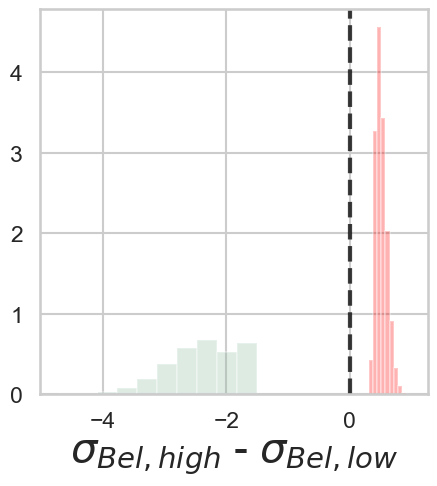

In [79]:
# Between-frame comparison (high-evidence frame trace first)
print("======= Experiment 1 =======")
showStats("sample_exp1_like_gammaPrior.nc", "sample_exp1_dislike_gammaPrior.nc")

======= Experiment 2 =======
Test Statistic: -644.2587685126657
P-Value: 0.0
Permutation Test Statistic: 4.3264869510459585
Permutation Test P-Value: 0.00019998000199980003


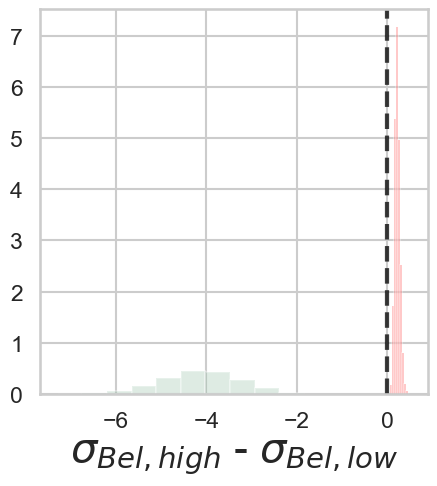

In [80]:
# Between-frame comparison (high-evidence frame trace first)
print("======= Experiment 2 =======")
showStats("sample_exp2_more_gamma.nc", "sample_exp2_less_gamma.nc")

======= Experiment 3 =======
Test Statistic: -189.7905372118453
P-Value: 0.0
Permutation Test Statistic: 0.8728972850673977
Permutation Test P-Value: 0.00019998000199980003


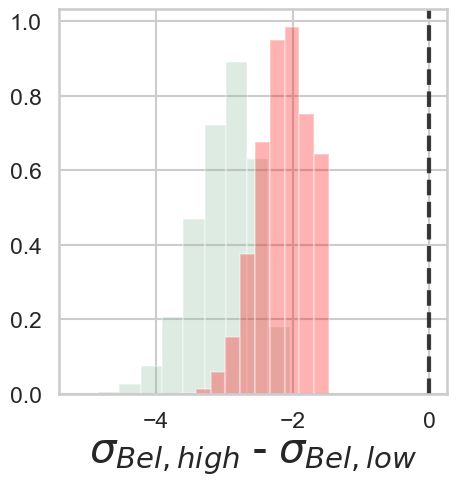

In [81]:
# Between-frame comparison (high-evidence frame trace first)
print("======= Experiment 3 =======")
showStats("sample_exp3_HighMotion_gammaPrior_v2.nc", "sample_exp3_LowMotion_gammaPrior.nc")

======= Experiment 4 =======
Test Statistic: -153.01439795198527
P-Value: 0.0
Permutation Test Statistic: 1.737348855348241
Permutation Test P-Value: 0.00019998000199980003


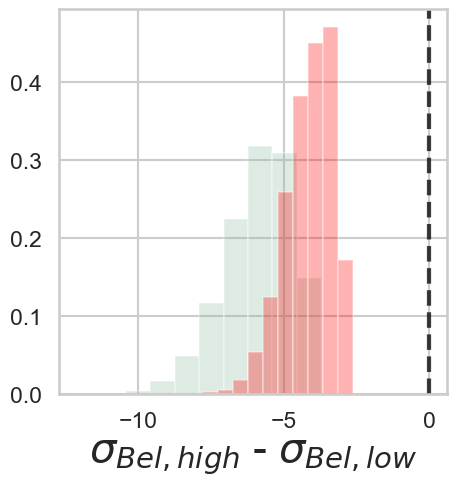

In [82]:
# Between-frame comparison (high-evidence frame trace first)
print("======= Experiment 4 =======")
showStats("sample_exp4_soundHigh_gammaPrior.nc", "sample_exp4_soundLow_gammaPrior.nc")